Corrected pilot 1: 2.00+2.00j
Corrected pilot 2: 2.00+2.00j


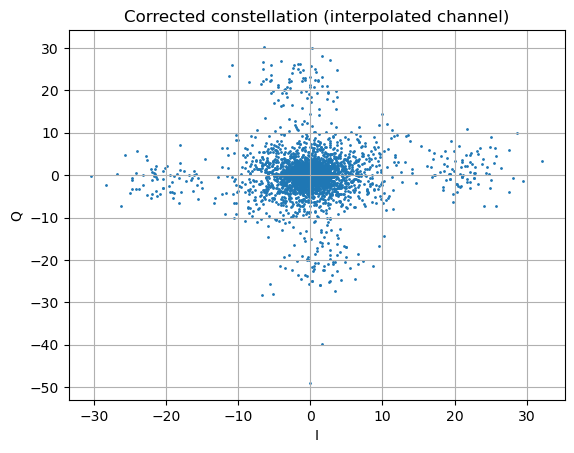

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# Load signal
data = scipy.io.loadmat('/Users/alicewesterberg/Desktop/wirelessproject/eitn21/Signals_task2/Signal1.mat')
r = data['R'].flatten()

# System parameters (same as Task 1)
fs = 44100
fc = 4000
N  = 100
Ns = len(r) // N

# Pulse shape
p = np.sin(np.pi * np.arange(N) / N)

# Carrier waves
n     = np.arange(Ns * N)
cos_c = np.cos(2 * np.pi * fc * n / fs)
sin_c = np.sin(2 * np.pi * fc * n / fs)

# Downconvert and matched filter
r_I = 2 * r[:Ns*N] * cos_c
r_Q = -2 * r[:Ns*N] * sin_c
y_I = r_I.reshape(Ns, N) @ p
y_Q = r_Q.reshape(Ns, N) @ p
y   = y_I + 1j * y_Q

# Channel estimation using both pilots (interpolated)
h_start  = y[0]  / (2 + 2j)
h_end    = y[-1] / (2 + 2j)
k        = np.arange(Ns)
h_interp = h_start + (h_end - h_start) * k / (Ns - 1)

# Correct all symbols
y_corrected = y / h_interp

print(f'Corrected pilot 1: {y_corrected[0]:.2f}')
print(f'Corrected pilot 2: {y_corrected[-1]:.2f}')

# Constellation plot (data symbols only, skip pilots)
plt.scatter(y_corrected[1:-1].real, y_corrected[1:-1].imag, s=1)
plt.xlabel('I'); plt.ylabel('Q')
plt.title('Corrected constellation (interpolated channel)')
plt.grid(); plt.show()